In [37]:
import cv2
import numpy as np
import torch.utils.data as data
import torch
import torch.optim as optim
import torch.nn as nn
from torchsummary import summary
import os
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import json
import pandas as pd
import copy
import torch.nn.functional as F
from math import exp
from typing import Optional
from datasets import SuperresDegradeDataset
from metrics import SSIM
from model_name import name_superres_model
from upscaler import Upscaler

np.random.seed(13)
torch.manual_seed(13)
torch.cuda.manual_seed(13)


In [38]:
DATASET_PATH = 'Div2K/'
PATH_TRAIN = DATASET_PATH + 'DIV2K_train_HR/'
PATH_TEST = DATASET_PATH + 'DIV2K_valid_HR/'
UPSCALE_MODELS_PATH = 'upscale_models/'

In [39]:
all_files = sorted(os.listdir(PATH_TRAIN))
split_idx = int(len(all_files)*0.9)
train_files = all_files[:split_idx]
val_files = all_files[split_idx:]
test_files = sorted(os.listdir(PATH_TEST))

In [40]:
loaded = False

In [41]:
parameters = {
    'architecture': 'SR', # SuperResolution
    'loss': 'MSE', # MSE, L1
    'learning_rate': 0.0001,
    'patch_size': 128,
    'scale_factor': 2,
    'num_blocks': 8,
    'early_stopping': False # True, False
}


In [42]:
model_name = name_superres_model(*parameters.values())

In [43]:
model_name

'SR_MSE_lr1e-04_ps128_sf2_nb8'

In [44]:
if 'upscale_models' not in os.listdir('./'):
    os.mkdir('upscale_models/')

In [45]:
if model_name in os.listdir(UPSCALE_MODELS_PATH) and not loaded:
    raise FileExistsError
elif model_name not in os.listdir(UPSCALE_MODELS_PATH) and loaded:
    raise FileNotFoundError

In [46]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [47]:
sr_train_set = SuperresDegradeDataset(PATH_TRAIN, train_files, parameters['patch_size'], parameters['scale_factor'])
sr_val_set = SuperresDegradeDataset(PATH_TRAIN, val_files, parameters['patch_size'], parameters['scale_factor'])

sr_test_set = SuperresDegradeDataset(PATH_TEST, test_files, parameters['patch_size'], parameters['scale_factor'], use_augm=False)

In [48]:
sr_train_loader = data.DataLoader(sr_train_set, batch_size=4, shuffle=True)
sr_val_loader = data.DataLoader(sr_val_set, batch_size=8, shuffle=False)
sr_test_loader = data.DataLoader(sr_test_set, batch_size=1, shuffle=False)

In [49]:
# class Upscaler(nn.Module):
#     def __init__(self, scale_factor=2, in_channels=3):
#         super().__init__()
#         self.scale_factor = scale_factor
        
#         self.net = nn.Sequential(
#             nn.Conv2d(in_channels, 64, 3, padding=1),
#             nn.ReLU(inplace=True),
            
#             nn.Conv2d(64, 64, 3, padding=1),
#             nn.ReLU(inplace=True), 
            
#             nn.Conv2d(64, in_channels*(scale_factor ** 2), 3, padding=1),
#             nn.PixelShuffle(scale_factor)
# 		)
#     def forward(self, x):
#         return self.net(x)

In [50]:
model = Upscaler(parameters['scale_factor'], num_blocks=parameters['num_blocks'])
model = model.to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=parameters['learning_rate'])

In [51]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min', 
    factor=0.8, 
    patience=5,
)

In [52]:
best_loss = float('inf')
patience_counter = 0
early_model_state = 15
best_model_state = None
final_epoch = None

In [53]:
ssim = SSIM()

In [54]:
if not loaded:
    epochs = 100
    train_loss_list = []
    val_loss_list = []
    psnr_list = []
    ssim_list = []
    lr_list = []
    
    for epoch in range(epochs):
        model.train()
        total_epoch_train_loss = 0
        for pair in sr_train_loader:
            
            img_lr, img_hr = pair[0].to(device), pair[1].to(device)
            optimizer.zero_grad()

            output = model(img_lr)
            loss = criterion(output, img_hr)
            loss.backward()
            optimizer.step()

            total_epoch_train_loss += loss.item()

        avg_train_loss = total_epoch_train_loss/len(sr_train_loader)
        train_loss_list.append(avg_train_loss)
        lr_list.append(scheduler.get_last_lr()[0])

        model.eval()
        total_epoch_val_loss = 0
        total_epoch_val_psnr = 0
        total_epoch_val_ssim = 0
        with torch.no_grad():
            for pair in sr_val_loader:
                img_lr, img_hr = pair[0].to(device), pair[1].to(device)

                output = model(img_lr)
                loss = criterion(output, img_hr)
        
                total_epoch_val_loss += loss.item()
                mse = torch.mean((output - img_hr)**2, dim=[1, 2, 3])
                total_epoch_val_psnr += 10 * torch.log10(1/(mse+1e-10)).mean().item()
                
                total_epoch_val_ssim += ssim(output, img_hr).item()

        avg_val_loss = total_epoch_val_loss / len(sr_val_loader)
        avg_val_psnr = total_epoch_val_psnr / len(sr_val_loader)
        avg_val_ssim = total_epoch_val_ssim / len(sr_val_loader)
        
        val_loss_list.append(avg_val_loss)
        psnr_list.append(avg_val_psnr)
        ssim_list.append(avg_val_ssim)

        print(f'Epoch: {epoch + 1}, Train loss: {avg_train_loss}, Val loss: {avg_val_loss}, Val PSNR: {avg_val_psnr}, Val SSIM: {avg_val_ssim}, Learning rate: {scheduler.get_last_lr()[0]}')

        scheduler.step(avg_val_loss)
        if parameters['early_stopping']:
            if avg_val_loss < best_loss:
                best_loss = avg_val_loss
                patience_counter = 0
                best_model_state = copy.deepcopy(model.state_dict()) # ?
                final_epoch = epoch

            else:
                patience_counter += 1
                if early_model_state == patience_counter:
                    epoch = final_epoch
                    model.load_state_dict(best_model_state)
                    break

Epoch: 1, Train loss: 0.015583226609871619, Val loss: 0.0030871609458699824, Val PSNR: 27.035439252853394, Val SSIM: 0.7430694341659546, Learning rate: 0.0001
Epoch: 2, Train loss: 0.002775379731449195, Val loss: 0.0024185204005334527, Val PSNR: 29.210756540298462, Val SSIM: 0.8307057201862336, Learning rate: 0.0001
Epoch: 3, Train loss: 0.0021783775659666087, Val loss: 0.0024160721339285375, Val PSNR: 27.60250234603882, Val SSIM: 0.803467845916748, Learning rate: 0.0001
Epoch: 4, Train loss: 0.0019808046706505894, Val loss: 0.001444363541668281, Val PSNR: 31.354663610458374, Val SSIM: 0.8752113163471222, Learning rate: 0.0001
Epoch: 5, Train loss: 0.0019074069234193303, Val loss: 0.0016348020115401595, Val PSNR: 31.074063777923584, Val SSIM: 0.8762615263462067, Learning rate: 0.0001
Epoch: 6, Train loss: 0.0018601076574769752, Val loss: 0.0013784438342554495, Val PSNR: 32.1804621219635, Val SSIM: 0.8928625345230102, Learning rate: 0.0001
Epoch: 7, Train loss: 0.0016300826331846312, Va

In [55]:
if model_name not in os.listdir(UPSCALE_MODELS_PATH) and not loaded:
    os.mkdir(UPSCALE_MODELS_PATH + model_name)

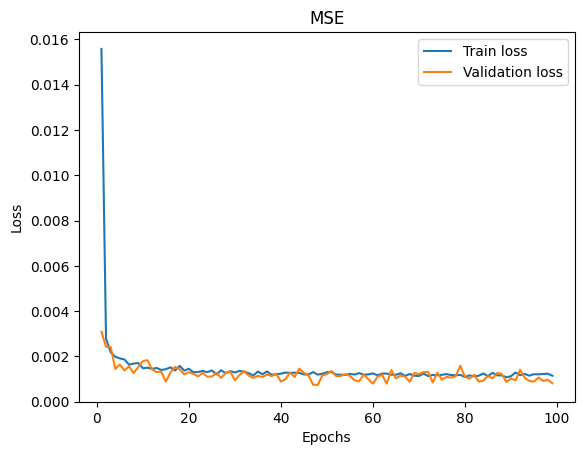

In [56]:
if not loaded:
    iteration_list = list(range(1, epoch+1))
    df = pd.DataFrame({'train_loss': train_loss_list, 'val_loss': val_loss_list, 'val_psnr': psnr_list,'lr': lr_list})
    df.to_csv(f'{UPSCALE_MODELS_PATH + model_name}/metrics.csv', index=False)  
    plt.plot(iteration_list, train_loss_list[:epoch])
    plt.plot(iteration_list, val_loss_list[:epoch])
    plt.legend(['Train loss','Validation loss'])
    
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(parameters['loss'])
    plt.savefig(f'{UPSCALE_MODELS_PATH}/{model_name}/loss_fig.png')
    plt.show()

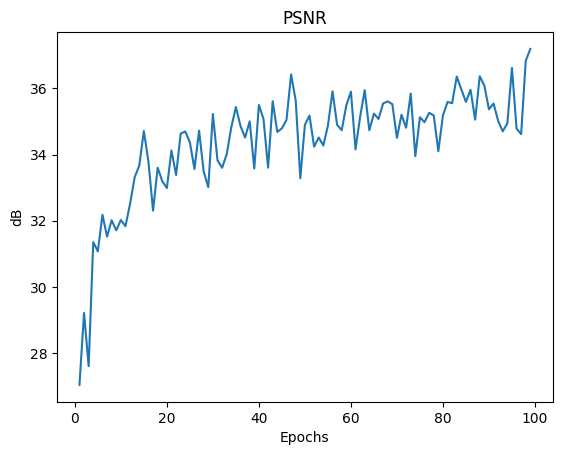

In [57]:
if not loaded:
    plt.plot(iteration_list, psnr_list[:epoch])
    plt.xlabel('Epochs')
    plt.ylabel('dB')
    plt.title('PSNR')
    plt.savefig(f'{UPSCALE_MODELS_PATH}/{model_name}/psnr_fig.png')
    plt.show()

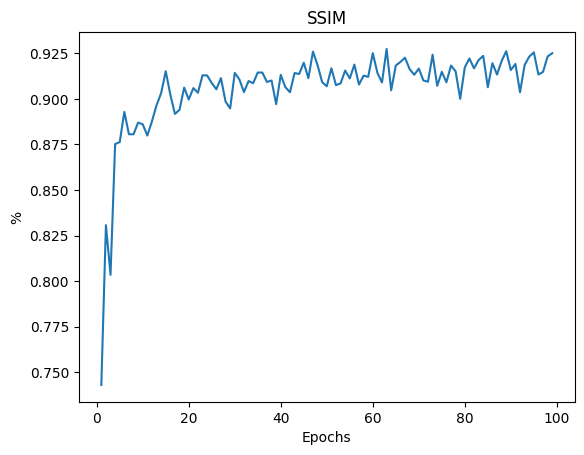

In [58]:
if not loaded:
    plt.plot(iteration_list, ssim_list[:epoch])
    plt.xlabel('Epochs')
    plt.ylabel('%')
    plt.title('SSIM')
    plt.savefig(f'{UPSCALE_MODELS_PATH}/{model_name}/ssim_fig.png')
    plt.show()

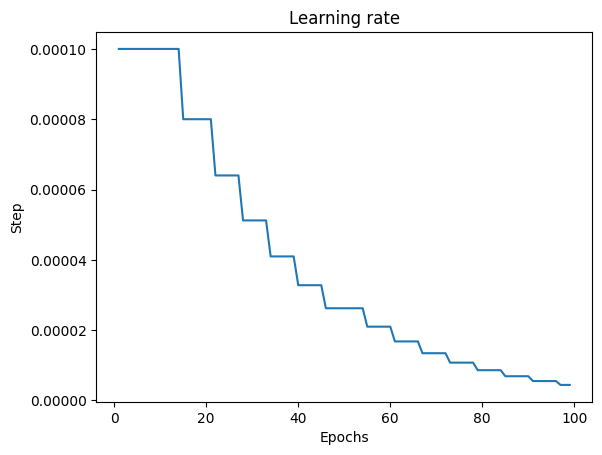

In [59]:
if not loaded:
    plt.plot(iteration_list, lr_list[:epoch])
    plt.xlabel('Epochs')
    plt.ylabel('Step')
    plt.title('Learning rate')
    plt.savefig(f'{UPSCALE_MODELS_PATH}/{model_name}/lr_fig.png')
    plt.show()

In [60]:
if loaded:
    model = torch.load(f'{UPSCALE_MODELS_PATH}/{model_name}/model.pth', weights_only=False)
    # model.load_state_dict(model_weights)
    

In [61]:
# SSIM

test_epoch_loss = 0
test_epoch_psnr = 0
test_epoch_ssim = 0

model.eval()
with torch.no_grad():
    for pair in sr_test_loader:
        img_lr, img_hr = pair[0].to(device), pair[1].to(device)
                        
        output = model(img_lr)
        loss = criterion(output, img_hr)
        mse = torch.mean((output - img_hr)**2, dim=[1, 2, 3])
        
        test_epoch_loss += loss.item()
        test_epoch_psnr += 10 * torch.log10(1/(mse+1e-10)).mean().item()
        
        test_epoch_ssim += ssim(output, img_hr).item()

print(f'Loss on the {len(sr_test_loader)} test images: {test_epoch_loss/len(sr_test_loader)}')
print(f'PSNR on the {len(sr_test_loader)} test images: {test_epoch_psnr/len(sr_test_loader)}')
print(f'PSNR on the {len(sr_test_loader)} test images: {test_epoch_ssim/len(sr_test_loader)}')



Loss on the 100 test images: 0.0012752008111783654
PSNR on the 100 test images: 35.042088901996614
PSNR on the 100 test images: 0.9186098724603653


In [62]:
if not loaded:
    df = pd.DataFrame({'PSNR': [test_epoch_psnr/len(sr_test_loader)],
                   'loss': [test_epoch_loss/len(sr_test_loader)],
                   'SSIM': [test_epoch_ssim/len(sr_test_loader)],
                   'params': [sum(p.numel() for p in model.parameters())],
                   'final_epoch': [epoch]})
    df.to_csv(f'{UPSCALE_MODELS_PATH}/{model_name}/test_metrics.csv', index=False)  

    torch.save(model, f'{UPSCALE_MODELS_PATH}/{model_name}/model.pth')
    
    with open(f'{UPSCALE_MODELS_PATH}/{model_name}/config.json', 'w', encoding='utf-8') as f:
        json.dump(parameters, f, indent=4, ensure_ascii=False)

In [63]:
lr, hr = next(iter(sr_test_loader))

In [64]:
with torch.no_grad():
    lr_cuda = lr.to(device)
    out = model(lr_cuda)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.008954288..0.96298313].


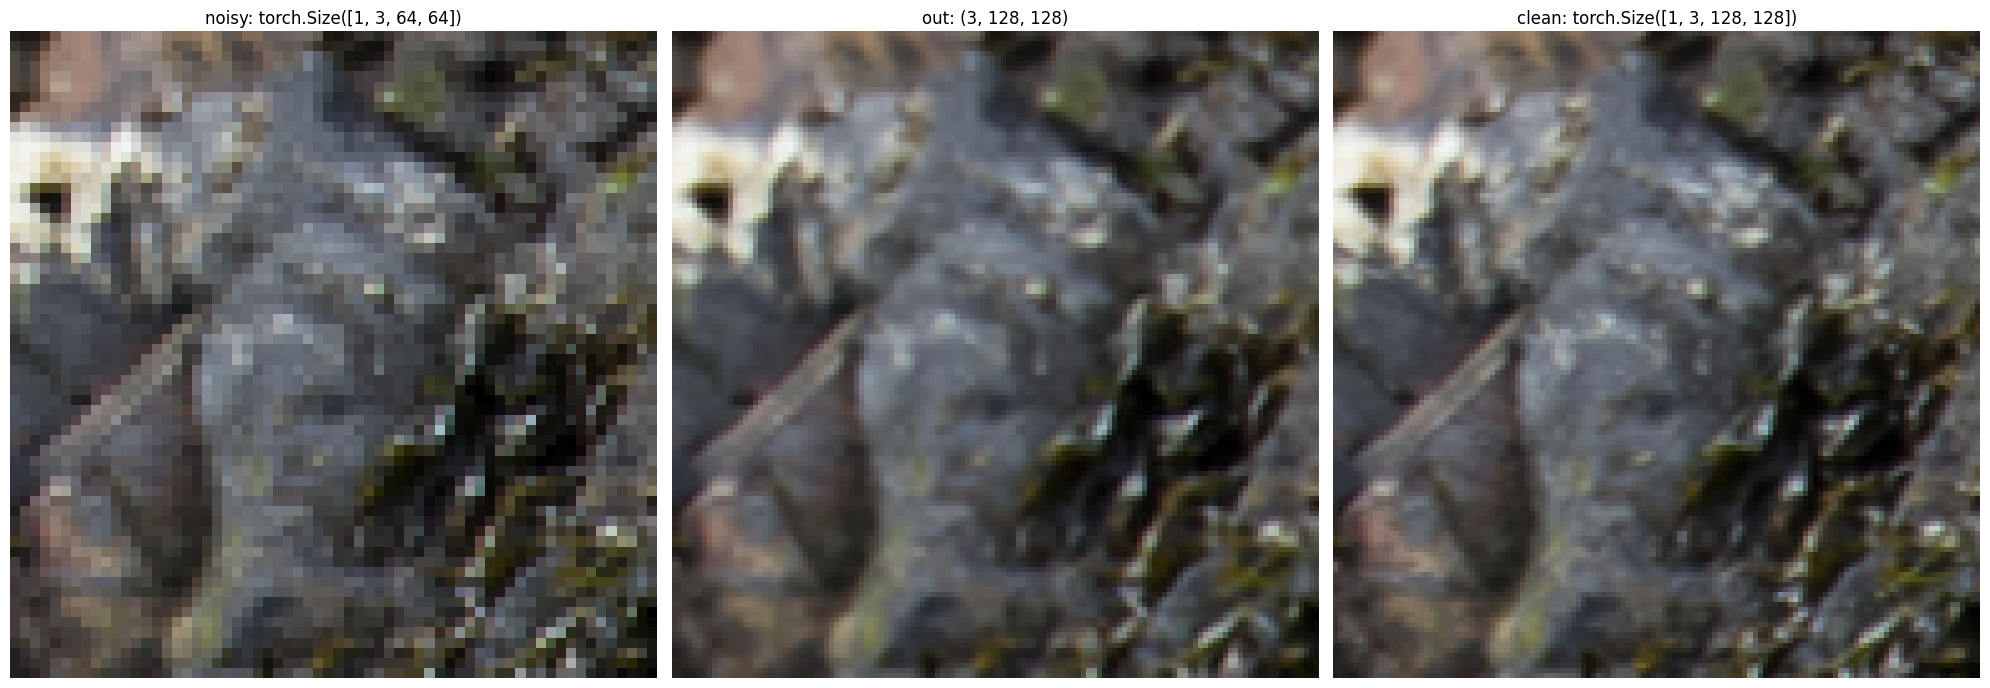

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(20, 15))

axes[0].imshow(np.transpose(lr[0][:3, :, :], (1, 2, 0)))
axes[0].set_title(f"noisy: {lr.shape}")
axes[0].axis('off')

axes[1].imshow(np.transpose(out.cpu().data.numpy()[0], (1, 2, 0)))
axes[1].set_title(f"out: {out.cpu().data.numpy()[0].shape}")
axes[1].axis('off')


axes[2].imshow(np.transpose(hr[0], (1, 2, 0)))
axes[2].set_title(f"clean: {hr.shape}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [66]:
import plyer
plyer.notification.notify(
    message='Всё',
    title=model_name, )